In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
import os
orders_path = os.path.join('..', 'output', 'orders.csv')
try:
    orders = pd.read_csv(orders_path)
    orders['order_date'] = orders['order_date'].astype(int)
    orders['sku_id'] = orders['sku_id'].astype(str)
    orders['campaign_applied'] = orders['campaign_applied'].astype(bool)
    orders.head()
except FileNotFoundError:
    print(f"File '{orders_path}' not found. Please ensure the file exists or update the path.")


In [3]:
orders["week"] = orders["order_date"] // 7

week_day_counts = orders.groupby("week")["order_date"].nunique()
full_weeks = week_day_counts[week_day_counts == 7].index

print("Dropped partial weeks:", sorted(set(week_day_counts.index) - set(full_weeks)))

orders = orders[orders["week"].isin(full_weeks)].copy()

assert (orders.groupby("week")["order_date"].nunique() == 7).all()


Dropped partial weeks: [104]


In [4]:
weekly = (
    orders
    .groupby(["week", "sku_id"], as_index=False)
    .agg(
        weekly_qty=("order_quantity", "sum"),
        campaign_days=("campaign_applied", "sum")
    )
)

weekly["campaign_intensity"] = weekly["campaign_days"] / 7
weekly.sort_values(["sku_id", "week"], inplace=True)

weekly.head()


,week,sku_id,weekly_qty,campaign_days,campaign_intensity
0,0,SKU0001,454,0,0.000000
5,1,SKU0001,1461,786,112.285714
10,2,SKU0001,2273,1380,197.142857
15,3,SKU0001,1301,651,93.000000
20,4,SKU0001,1502,954,136.285714


In [5]:
sku_id = (
    weekly.groupby("sku_id")["week"]
    .count()
    .sort_values(ascending=False)
    .index[0]
)

print("Selected SKU:", sku_id)

sku_df = weekly[weekly["sku_id"] == sku_id].copy()
sku_df.reset_index(drop=True, inplace=True)


Selected SKU: SKU0001


In [6]:
split_week = int(sku_df["week"].max() * 0.8)

train_df = sku_df[sku_df["week"] <= split_week].copy()
val_df   = sku_df[sku_df["week"] > split_week].copy()

print("Train weeks:", train_df["week"].nunique())
print("Validation weeks:", val_df["week"].nunique())



Train weeks: 83
Validation weeks: 21


In [7]:
from typing import cast
from statsmodels.tsa.statespace.sarimax import SARIMAXResults

model = SARIMAX(
    train_df["weekly_qty"],
    exog=train_df[["campaign_intensity"]],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# cast to SARIMAXResults to satisfy static type checkers, then show summary
results = cast(SARIMAXResults, results)
results.summary()


c:\Users\ACER\OneDrive\Documents\GitHub\StockIQ\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\ACER\OneDrive\Documents\GitHub\StockIQ\venv\Lib\site-packages\statsmodels\tools\eval_measures.py:414: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
c:\Users\ACER\OneDrive\Documents\GitHub\StockIQ\venv\Lib\site-packages\statsmodels\tools\eval_measures.py:439: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + 2 * np.log(np.log(nobs)) * df_modelwc
c:\Users\ACER\OneDrive\Documents\GitHub\StockIQ\venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse
c:\Users\ACER\OneDrive\Documents\GitHub\StockIQ\v

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         weekly_qty   No. Observations:                   83
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                   0.000
Date:                            Tue, 23 Dec 2025   AIC                             12.000
Time:                                    11:05:57   BIC                                nan
Sample:                                         0   HQIC                               nan
                                             - 83                                         
Covariance Type:                              opg                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
campaign_intensity     8.6713         -0       -inf      0.000       8.671       8.671
ar.L1                  0.0329         -0       -inf      0.000       0.033       0.033
ma.L1                 -0.0182         -0        inf      0.000      -0.018      -0.018
ar.S.L52                    0         -0        nan        nan           0           0
ma.S.L52                    0         -0        nan        nan           0           0
sigma2               763.3182         -0       -inf      0.000     763.318     763.318
===================================================================================
Ljung-Box (L1) (Q):                    nan   Jarque-Bera (JB):                  nan
Prob(Q):                               nan   Prob(JB):                          nan
Heteroskedasticity (H):                nan   Skew:                              nan
Prob(H) (two-sided):                   nan   Kurtosis:                          nan
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number    inf. Standard errors may be unstable.
"""

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
from typing import cast

results_cast = cast(SARIMAXResults, results)

val_pred = results_cast.get_forecast(
    steps=len(val_df),
    exog=val_df[["campaign_intensity"]]
)

val_df["p50"] = val_pred.predicted_mean.values

val_mape = mean_absolute_percentage_error(
    val_df["weekly_qty"],
    val_df["p50"]
)

val_mape


0.02998367561277033

In [10]:
# Use the already-cast results object (defined earlier) so fittedvalues is available
fitted = np.asarray(results_cast.fittedvalues)

# Align and drop NaNs that can appear at the beginning due to differencing
actual = train_df["weekly_qty"].to_numpy(dtype=float)
mask = np.isfinite(fitted) & np.isfinite(actual)

train_residuals = actual[mask] - fitted[mask]

q10 = np.percentile(train_residuals, 10)
q90 = np.percentile(train_residuals, 90)

print("Residual quantiles (q10, q90):", q10, q90)



Residual quantiles (q10, q90): -28.765256402325402 27.656449293641778


In [11]:
val_df["p10"] = val_df["p50"] + q10
val_df["p90"] = val_df["p50"] + q90

coverage = (
    (val_df["weekly_qty"] >= val_df["p10"]) &
    (val_df["weekly_qty"] <= val_df["p90"])
).mean()


coverage


np.float64(0.8571428571428571)

In [12]:
FORECAST_HORIZON = 12  # weeks

last_week = sku_df["week"].max()
future_weeks = np.arange(last_week + 1, last_week + 1 + FORECAST_HORIZON)

# assume no campaign by default (API can override this later)
future_campaign = np.zeros(FORECAST_HORIZON)

future_pred = results_cast.get_forecast(
    steps=FORECAST_HORIZON,
    exog=pd.DataFrame({"campaign_intensity": future_campaign})
)

future_df = pd.DataFrame({
    "week": future_weeks,
    "p50": future_pred.predicted_mean.values
})

future_df["p10"] = future_df["p50"] + q10
future_df["p90"] = future_df["p50"] + q90

future_df


,week,p50,p10,p90
0,104,475.064608,446.299352,502.721058
1,105,449.066736,420.301480,476.723186
2,106,448.066806,419.301550,475.723256
3,107,467.066809,438.301552,494.723258
4,108,475.066809,446.301552,502.723258
5,109,470.066809,441.301552,497.723258
6,110,467.066809,438.301552,494.723258
7,111,475.066809,446.301552,502.723258
8,112,465.066809,436.301552,492.723258
9,113,455.066809,426.301552,482.723258


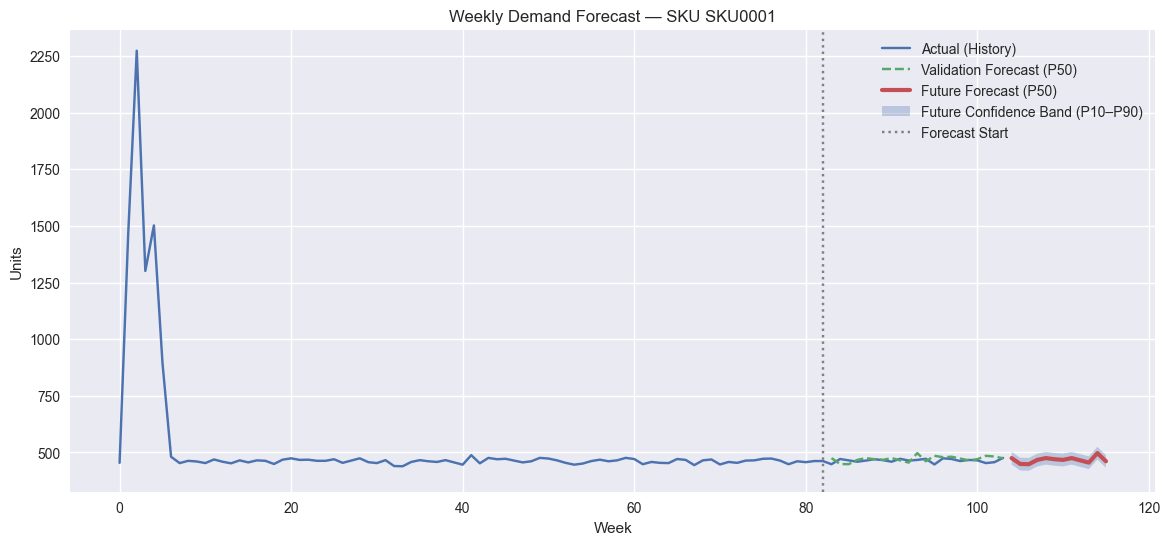

In [13]:
plt.figure(figsize=(14,6))

# history
plt.plot(sku_df["week"], sku_df["weekly_qty"], label="Actual (History)")

# validation forecast
plt.plot(val_df["week"], val_df["p50"], label="Validation Forecast (P50)", linestyle="--")

# future forecast
plt.plot(future_df["week"], future_df["p50"], label="Future Forecast (P50)", linewidth=3)

plt.fill_between(
    future_df["week"],
    future_df["p10"],
    future_df["p90"],
    alpha=0.3,
    label="Future Confidence Band (P10–P90)"
)

plt.axvline(split_week, color="gray", linestyle=":", label="Forecast Start")

plt.title(f"Weekly Demand Forecast — SKU {sku_id}")
plt.xlabel("Week")
plt.ylabel("Units")
plt.legend()
plt.show()


In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [15]:
required_cols = {"weekly_qty", "p50", "p10", "p90"}
missing = required_cols - set(val_df.columns)
assert not missing, f"Missing columns: {missing}"

val = val_df.copy()


In [16]:
# MAPE
mape = np.mean(np.abs((val["weekly_qty"] - val["p50"]) / val["weekly_qty"]))

# MAE
mae = mean_absolute_error(val["weekly_qty"], val["p50"])

# RMSE
rmse = np.sqrt(mean_squared_error(val["weekly_qty"], val["p50"]))


In [17]:
bias = np.mean(val["p50"] - val["weekly_qty"])


In [18]:
coverage = (
    (val["weekly_qty"] >= val["p10"]) &
    (val["weekly_qty"] <= val["p90"])
).mean()


In [19]:
# % of times actual demand exceeded P50 forecast
stockout_rate = (val["weekly_qty"] > val["p50"]).mean()


In [20]:
over_forecast_rate = (val["weekly_qty"] < val["p50"]).mean()


In [21]:
metrics = pd.DataFrame(
    {
        "Metric": [
            "MAPE",
            "MAE (units)",
            "RMSE (units)",
            "Bias (mean error)",
            "Coverage P10–P90",
            "Stockout Proxy Rate",
            "Over-Forecast Rate"
        ],
        "Value": [
            round(mape, 4),
            round(mae, 2),
            round(rmse, 2),
            round(bias, 2),
            round(coverage, 3),
            round(stockout_rate, 3),
            round(over_forecast_rate, 3)
        ]
    }
)

metrics


,Metric,Value
0,MAPE,0.030
1,MAE (units),13.780
2,RMSE (units),17.580
3,Bias (mean error),7.160
4,Coverage P10–P90,0.857
5,Stockout Proxy Rate,0.333
6,Over-Forecast Rate,0.667
